In [1]:
## Test for Antoine
import h5py
import numpy as np
import matplotlib.pyplot as plt
file_path = r"Data\Donnes\New_Data\20250624\Haut glucose (16.7mM)_1min.h5" 


with h5py.File(file_path, "r") as f:
    def print_structure(name, obj):
        print(name, "|", type(obj))

    f.visititems(print_structure)

Data | <class 'h5py._hl.group.Group'>
Data/Recording_0 | <class 'h5py._hl.group.Group'>
Data/Recording_0/AnalogStream | <class 'h5py._hl.group.Group'>
Data/Recording_0/AnalogStream/Stream_0 | <class 'h5py._hl.group.Group'>
Data/Recording_0/AnalogStream/Stream_0/ChannelData | <class 'h5py._hl.dataset.Dataset'>
Data/Recording_0/AnalogStream/Stream_0/ChannelDataTimeStamps | <class 'h5py._hl.dataset.Dataset'>
Data/Recording_0/AnalogStream/Stream_0/InfoChannel | <class 'h5py._hl.dataset.Dataset'>


In [2]:
with h5py.File(file_path, "r") as f:
    def print_datasets(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"{name} | shape={obj.shape} | dtype={obj.dtype}")

    f.visititems(print_datasets)


Data/Recording_0/AnalogStream/Stream_0/ChannelData | shape=(60, 938000) | dtype=int32
Data/Recording_0/AnalogStream/Stream_0/ChannelDataTimeStamps | shape=(1, 3) | dtype=int64
Data/Recording_0/AnalogStream/Stream_0/InfoChannel | shape=(60,) | dtype=[('ChannelID', '<i4'), ('RowIndex', '<i4'), ('GroupID', '<i4'), ('ElectrodeGroup', '<i4'), ('Label', 'O'), ('RawDataType', 'O'), ('Unit', 'O'), ('Exponent', '<i4'), ('ADZero', '<i4'), ('Tick', '<i8'), ('ConversionFactor', '<i8'), ('ADCBits', '<i4'), ('HighPassFilterType', 'O'), ('HighPassFilterCutOffFrequency', 'O'), ('HighPassFilterOrder', '<i4'), ('LowPassFilterType', 'O'), ('LowPassFilterCutOffFrequency', 'O'), ('LowPassFilterOrder', '<i4')]


In [12]:
import pandas as pd


file_path = r"Data\Donnes\New_Data\20250624\Haut glucose (16.7mM)_1min.h5"

with h5py.File(file_path, "r") as f:
    info = f["Data/Recording_0/AnalogStream/Stream_0/InfoChannel"]
    info_np = info[:]

df = pd.DataFrame(info_np)

df.to_excel('Metadatos.xlsx')
print(df.head()) 

   ChannelID  RowIndex  GroupID  ElectrodeGroup  Label RawDataType  Unit  \
0          0         0        0               0  b'47'      b'Int'  b'V'   
1          1         1        0               0  b'48'      b'Int'  b'V'   
2          2         2        0               0  b'46'      b'Int'  b'V'   
3          3         3        0               0  b'45'      b'Int'  b'V'   
4          4         4        0               0  b'38'      b'Int'  b'V'   

   Exponent  ADZero  Tick  ConversionFactor  ADCBits HighPassFilterType  \
0       -12       0   100            104166       16                b''   
1       -12       0   100            104166       16                b''   
2       -12       0   100            104166       16                b''   
3       -12       0   100            104166       16                b''   
4       -12       0   100            104166       16                b''   

  HighPassFilterCutOffFrequency  HighPassFilterOrder LowPassFilterType  \
0                 

In [ ]:
file_path = r"Data\Donnes\New_Data\20250624\Haut glucose (16.7mM)_1min.h5"

with h5py.File(file_path, "r") as f:
    data = f["Data/Recording_0/AnalogStream/Stream_0/ChannelData"]
    info = f["Data/Recording_0/AnalogStream/Stream_0/InfoChannel"]

    signals_raw = data[:]
    info_np = info[:]  



## The physical reconstruction is:
$$ \text{Physical Value} = (\text{Raw} - \text{Offset}) \times \text{Scale} $$

### Signal Conversion Formula


$$ \text{signals} = (\text{signals\_raw} - \text{ADZero}) \times \text{factor} \times (10^{\text{exponent}}) $$

---

### 🔍 Meaning of Each Term

### 1. `signals_raw` - Raw ADC Value

| Property | Description |
|----------|-------------|
| **Type** | Integer from ADC |
| **Range** | -2,147,483,648 to +2,147,483,647 (32-bit signed) |
| **Physical Unit** | None (dimensionless counts) |

The raw value directly from the analog-to-digital converter before any processing.

---

### 2. `ADZero` - Offset Correction

This is the baseline offset of the ADC.

#### Why it exists:
- Electronics are not perfectly centered at 0
- The "zero voltage" may map to a non-zero integer value
- Removes systematic DC offset from the measurement

#### The Operation:
$$ \text{signals\_raw} - \text{ADZero} $$

👉 **Recenters the signal around true zero volts**



---

### 3. `factor` - Conversion Factor (Gain Scaling)

This converts ADC counts into volts or the base physical unit.

#### Concept:
$$ 1 \text{ count} = X \text{ volts} $$

#### The Operation:
$$ (\text{raw} - \text{offset}) \times \text{factor} $$

👉 **Gives voltage in base unit (before exponent)**


### 4. `exponent` - Unit Scaling

This applies scientific notation scaling to convert to final physical units.

#### Common Exponent Values:

| Exponent | Prefix | Symbol | Unit Example |
|----------|--------|--------|--------------|
| -12 | pico | p | pV, pA |
| -9 | nano | n | nV, nA |
| -6 | micro | µ | µV, µA |
| -3 | milli | m | mV, mA |
| 0 | none | - | V, A |
| 3 | kilo | k | kV, kA |

#### The Operation:
$$ \text{factor} \times (10^{\text{exponent}}) $$

👉 **Applies final scaling to physical units**



In [16]:

ADZero = info_np["ADZero"][:, None]
factor = info_np["ConversionFactor"][:, None]
exponent = info_np["Exponent"][:, None]

signals = (signals_raw - ADZero) * factor * (10.0 ** exponent) ## signal converted from ADC counts (digital integers) to Volts


Sampling rate: 10000
-12.708252 17.499888


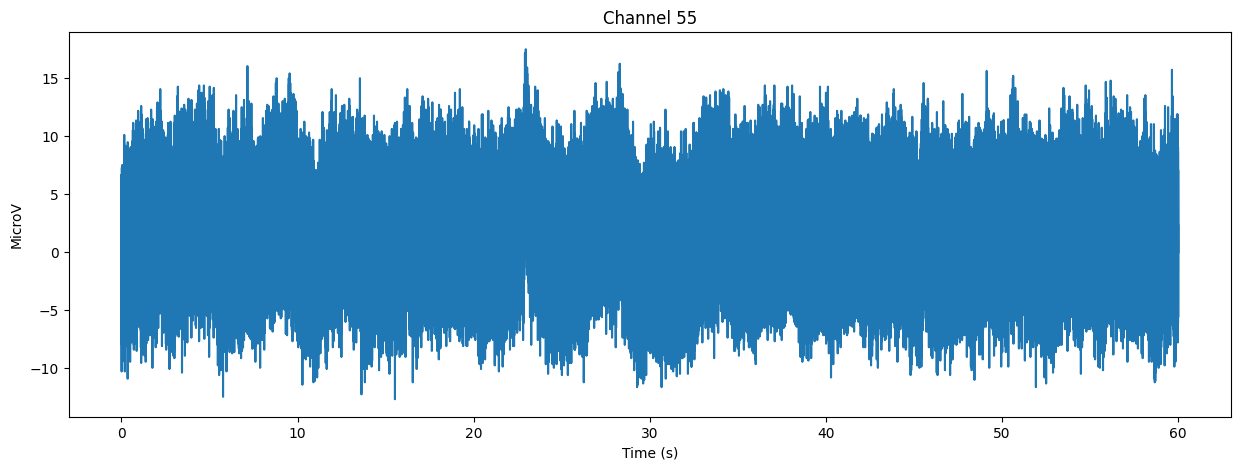

In [17]:

tick = info_np[0]["Tick"]  # in microseconds typically
fs = int(1e6 / tick)        # Hz

print("Sampling rate:", fs)

skip_s = 0 
length_s = 60
ch = 55

Single_segment_channel = signals[ch, (skip_s*fs):(length_s*fs)]*1e6 ## select single channel, a fragment, and convert volts to microvolts.

print(Single_segment_channel.min(), Single_segment_channel.max())

L = len(Single_segment_channel)

time = np.linspace(start=skip_s, stop=skip_s + L/fs, num=L, endpoint=False)



plt.figure(figsize=(15,5))
plt.plot(time, Single_segment_channel)
plt.xlabel("Time (s)")
plt.ylabel("MicroV")
plt.title(f"Channel {ch}")
plt.show()
